# 신용카드사기탐지_모델만들기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

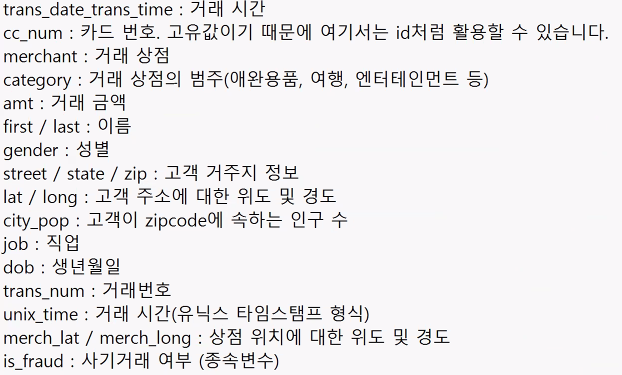

In [2]:
data = pd.read_csv('./data/fraud.csv')
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [4]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [34]:
data['trans_num'].value_counts()

trans_num
1765bb45b3aa3224b4cdcb6e7a96cee3    1
0b242abb623afc578575680df30655b9    1
1f76529f8574734946361c461b024d99    1
a1a22d70485983eac12b5b88dad1cf95    1
6b849c168bdad6f867558c3793159a81    1
                                   ..
413636e759663f264aae1819a4d4f231    1
8a6293af5ed278dea14448ded2685fea    1
baae0b096835c975857eea7e28dde3dc    1
991c04803b4d4eeab30d6245a872e3d3    1
f12cf52be2175703db789a4644c32f25    1
Name: count, Length: 1852394, dtype: int64

In [5]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [6]:
from ydata_profiling import ProfileReport

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
profile = ProfileReport(data,title='Profiling Report')
profile.to_file("fraud_eda.html")

Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 30.58it/s]


In [8]:
data.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [9]:
data['cc_num'].value_counts()

cc_num
6538441737335434       4392
30270432095985         4392
4642255475285942       4386
6538891242532018       4386
4364010865167176       4386
                       ... 
4352307151555405069       7
501894933032              7
4975457191020             7
6577777028615915          7
4295296907373             6
Name: count, Length: 999, dtype: int64

In [12]:
data.loc[data['is_fraud'] == 1, 'cc_num'].value_counts()

cc_num
4593569795412       19
3520550088202337    19
4599285557366057    19
4260128500325       18
6538441737335434    18
                    ..
3518234918950662     2
3576431665303017     2
4809701904914        2
4514242065619750     2
6011109736646996     2
Name: count, Length: 976, dtype: int64

In [21]:
data.loc[data['is_fraud'] == 1, ['cc_num', 'is_fraud']].value_counts()

cc_num            is_fraud
4599285557366057  1           19
3520550088202337  1           19
4593569795412     1           19
4260128500325     1           18
6538441737335434  1           18
                              ..
3518234918950662  1            2
4809701904914     1            2
3576431665303017  1            2
6011109736646996  1            2
6011893664860915  1            2
Name: count, Length: 976, dtype: int64

In [26]:
data[data['cc_num']==4809701904914]

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1228,2019-01-01 14:33:20,4809701904914,fraud_Bogisich-Weimann,kids_pets,42.52,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,4a964ababee2cb4830caca4735781f37,1325428400,31.566317,-84.757791,0
1935,2019-01-01 20:01:00,4809701904914,fraud_Watsica LLC,personal_care,30.94,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,90d0c26cfc04e17d39b68f47f4a955b1,1325448060,33.166736,-86.009983,0
2100,2019-01-01 21:23:05,4809701904914,fraud_Crona and Sons,kids_pets,19.60,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,c79e94f918604141348966e350f24e8d,1325452985,32.614841,-84.187913,0
3214,2019-01-02 18:45:51,4809701904914,"fraud_Zboncak, Rowe and Murazik",shopping_net,1.25,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,cb36bb578853e1d9623adc15c2584488,1325529951,33.070310,-85.682877,0
3238,2019-01-02 19:04:03,4809701904914,fraud_Predovic Inc,shopping_net,1.43,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,df00703e443d1239e0a9687c41dfd839,1325531043,33.205590,-84.806941,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849755,2020-12-31 06:59:43,4809701904914,fraud_Kutch and Sons,grocery_pos,208.79,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,5b60213623d2932c6ac18222bbbdf882,1388473183,31.902890,-85.095022,0
1850763,2020-12-31 14:30:31,4809701904914,"fraud_Bins, Balistreri and Beatty",shopping_pos,3.75,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,19375c1c15d98b01475b482f506ab644,1388500231,33.313183,-85.279480,0
1850899,2020-12-31 15:24:59,4809701904914,"fraud_Schneider, Hayes and Nikolaus",food_dining,100.81,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,3aeb24e89ec28ef361747e1c477bb2c7,1388503499,33.034548,-85.016004,0
1850968,2020-12-31 15:50:06,4809701904914,fraud_Reichel LLC,personal_care,20.76,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,1d966f70f49a121fa43bacb771f383f8,1388505006,32.774329,-85.258189,0


In [27]:
data[(data['cc_num']==4809701904914) & (data['is_fraud']==1)]

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
757471,2019-11-20 03:16:11,4809701904914,"fraud_Monahan, Bogisich and Ledner",misc_pos,8.32,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,175d7c100c402f3fd715be5b3e557db8,1353381371,32.354366,-84.447639,1
758889,2019-11-20 22:59:39,4809701904914,fraud_Hirthe-Beier,health_fitness,17.08,Sabrina,Nolan,F,312 Eric Expressway Apt. 014,Phenix City,...,32.4204,-85.0796,59744,Chemical engineer,1984-02-07,56ea1bbaaea9c6777aac19c3741108a0,1353452379,32.135552,-85.331899,1


In [29]:
data.loc[data['cc_num']==4809701904914, 'category'].value_counts()

category
shopping_pos      314
home              296
grocery_pos       273
shopping_net      272
kids_pets         253
personal_care     249
entertainment     211
grocery_net       195
health_fitness    191
misc_pos          191
food_dining       172
misc_net          148
gas_transport      94
travel             61
Name: count, dtype: int64

4593569795412

In [30]:
data[data['cc_num']==4593569795412]

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
93528,2019-02-25 00:34:27,4593569795412,fraud_Vandervort-Funk,grocery_pos,298.70,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,43a5746a8165b23bd2d6283f7265f2d8,1330130067,39.949010,-96.703476,1
93556,2019-02-25 00:57:23,4593569795412,"fraud_Christiansen, Goyette and Schamberger",gas_transport,10.44,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,fc4e9d84b88e44d4465245715677be3d,1330131443,41.029483,-98.428136,1
93565,2019-02-25 01:04:45,4593569795412,fraud_Kunze Inc,grocery_pos,300.27,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,c61ceef3958f2c40287b16333546c3bf,1330131885,39.413321,-98.075579,1
93578,2019-02-25 01:11:49,4593569795412,fraud_Wolf Inc,grocery_pos,299.49,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,d036afe677ad985b7bc2509e253f79e2,1330132309,39.785211,-96.608960,1
93674,2019-02-25 02:16:44,4593569795412,fraud_Berge LLC,gas_transport,9.21,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,dba24c469b4c30e90e3d4b4442268dc2,1330136204,39.303936,-96.976292,1
93778,2019-02-25 03:42:41,4593569795412,fraud_Kiehn-Emmerich,grocery_pos,285.81,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,b9f2addd3b2303ec26e44745a7a4e7ac,1330141361,40.990782,-97.605382,1
94641,2019-02-25 14:12:02,4593569795412,fraud_Larkin Ltd,kids_pets,20.27,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,9489a2ebad87e7590cd5559e54ece80f,1330179122,39.465551,-98.369363,1
95564,2019-02-25 22:03:59,4593569795412,fraud_Cormier LLC,shopping_net,1165.94,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,24280e9bda7ebd633a90863516978f55,1330207439,39.497113,-96.492329,1
95567,2019-02-25 22:04:59,4593569795412,"fraud_Langworth, Boehm and Gulgowski",shopping_net,942.93,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,c506ec3c282524adcf5309dc9be3f8aa,1330207499,40.562529,-97.870020,1
95606,2019-02-25 22:25:24,4593569795412,fraud_Boyer PLC,shopping_net,1078.92,Chelsea,Silva,F,5205 Annette Islands Apt. 043,Hubbell,...,40.0456,-97.4735,121,Set designer,1996-04-04,d20c04b08dc457176826da6b4db4bade,1330208724,40.281654,-97.399513,1


In [ ]:
data[(data['cc_num']==4593569795412) & (data['is_fraud']==1)]

In [31]:
fraud_cc = data.loc[data['is_fraud'] == 1, 'cc_num']

In [33]:
for num in fraud_cc:
    print('='*30, num, '='*30)
    print(len(data[data['cc_num']==num]))
    print(len(data[(data['cc_num']==num) & (data['is_fraud']==1)]))

============================== 4613314721966 ==============================
2194
8
============================== 340187018810220 ==============================
7
7
============================== 340187018810220 ==============================
7
7
============================== 4613314721966 ==============================
2194
8
============================== 340187018810220 ==============================
7
7
============================== 4613314721966 ==============================
2194
8
============================== 4613314721966 ==============================
2194
8
============================== 340187018810220 ==============================
7
7
============================== 340187018810220 ==============================
7
7
============================== 340187018810220 ==============================
7
7
============================== 4922710831011201 ==============================
1470
12
============================== 4922710831011201 ==============================
1470
12
==

1466
11
============================== 6526955903501879 ==============================
741
11
============================== 6526955903501879 ==============================
741
11
============================== 3513618443244549 ==============================
2919
4
============================== 6526955903501879 ==============================
741
11
============================== 6526955903501879 ==============================
741
11
============================== 3513618443244549 ==============================
2919
4
============================== 4587577161160601 ==============================
2931
14
============================== 2348245054386329 ==============================
2198
11
============================== 4587577161160601 ==============================
2931
14
============================== 4587577161160601 ==============================
2931
14
============================== 4587577161160601 ==============================
2931
14
============================== 2348245054

739
9
============================== 4377338765909719 ==============================
2924
7
============================== 180031190491743 ==============================
3655
14
============================== 4979422371139333 ==============================
2924
11
============================== 4979422371139333 ==============================
2924
11
============================== 4377338765909719 ==============================
2924
7
============================== 180031190491743 ==============================
3655
14
============================== 3595192916105588 ==============================
3654
12
============================== 4789911625179723 ==============================
741
14
============================== 3511058278399773 ==============================
738
9
============================== 3595192916105588 ==============================
3654
12
============================== 4789911625179723 ==============================
741
14
============================== 43773387659097

742
12
============================== 3541554378551366 ==============================
742
12
============================== 340951438290556 ==============================
2199
11
============================== 3541554378551366 ==============================
742
12
============================== 3541554378551366 ==============================
742
12
============================== 4277232699798846 ==============================
2193
6
============================== 4277232699798846 ==============================
2193
6
============================== 4220345354880 ==============================
2200
12
============================== 340951438290556 ==============================
2199
11
============================== 3541554378551366 ==============================
742
12
============================== 4586810168620942 ==============================
4384
10
============================== 4586810168620942 ==============================
4384
10
============================== 340951438290556 

10
============================== 4209696857872688515 ==============================
739
9
============================== 4247921790666 ==============================
2189
8
============================== 4247921790666 ==============================
2189
8
============================== 4247921790666 ==============================
2189
8
============================== 676234256292 ==============================
736
10
============================== 676234256292 ==============================
736
10
============================== 4209696857872688515 ==============================
739
9
============================== 4209696857872688515 ==============================
739
9
============================== 676234256292 ==============================
736
10
============================== 676234256292 ==============================
736
10
============================== 4209696857872688515 ==============================
739
9
============================== 4209696857872688515 =================

...

12
============================== 30487648872433 ==============================
1470
12
============================== 30487648872433 ==============================
1470
12
============================== 30242921189660 ==============================
1464
7
============================== 30487648872433 ==============================
1470
12
============================== 3535808924394848 ==============================
2194
8
============================== 30487648872433 ==============================
1470
12
============================== 30487648872433 ==============================
1470
12
============================== 30487648872433 ==============================
1470
12
============================== 30487648872433 ==============================
1470
12
============================== 30487648872433 ==============================
1470
12
============================== 30487648872433 ==============================
1470
12
============================== 378006354724784 ===============

12
============================== 180046165512893 ==============================
1472
12
============================== 30546453310167 ==============================
1470
12
============================== 4505383113689 ==============================
1465
7
============================== 4505383113689 ==============================
1465
7
============================== 30546453310167 ==============================
1470
12
============================== 180046165512893 ==============================
1472
12
============================== 5410056176712193 ==============================
737
9
============================== 180046165512893 ==============================
1472
12
============================== 3587044315915002 ==============================
2196
12
============================== 180046165512893 ==============================
1472
12
============================== 3587044315915002 ==============================
2196
12
============================== 5410056176712193 ==========

9
============================== 213156747557083 ==============================
3648
9
============================== 4292743669224718067 ==============================
2189
8
============================== 4292743669224718067 ==============================
2189
8
============================== 630423337322 ==============================
4362
7
============================== 630423337322 ==============================
4362
7
============================== 3564182536169293 ==============================
1462
10
============================== 213156747557083 ==============================
3648
9
============================== 4292743669224718067 ==============================
2189
8
============================== 4292743669224718067 ==============================
2189
8
============================== 3564182536169293 ==============================
1462
10
============================== 3564182536169293 ==============================
1462
10
============================== 4412720572684931

13
============================== 4560395181594436016 ==============================
2925
13
============================== 3596357274378601 ==============================
2909
7
============================== 4607072969078276 ==============================
2193
13
============================== 3596357274378601 ==============================
2909
7
============================== 3596217206093829 ==============================
4375
14
============================== 3596357274378601 ==============================
2909
7
============================== 4607072969078276 ==============================
2193
13
============================== 4607072969078276 ==============================
2193
13
============================== 3596217206093829 ==============================
4375
14
============================== 3596357274378601 ==============================
2909
7
============================== 4607072969078276 ==============================
2193
13
============================== 3596217206

4365
11
============================== 4716561796955522 ==============================
4365
11
============================== 4716561796955522 ==============================
4365
11
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10
============================== 2242176657877538 ==============================
10
10


In [1]:
import pandas as pd
import numpy as np

# 1) 데이터 불러오기 & 중복/이상치 제거
df = pd.read_csv('./data/fraud.csv')
df = df.drop_duplicates(subset='trans_num')               
df = df[(df['amt'] > 0) & (df['amt'] < 1e5)]              

# 2) 타입 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')
df['dob']                  = pd.to_datetime(df['dob'], errors='coerce')

# 3) 나이(age) 계산
current_year = 2025
df['age'] = current_year - df['dob'].dt.year

# 4) 시간 관련 피처
df['hour']      = df['trans_date_trans_time'].dt.hour
df['dayofweek'] = df['trans_date_trans_time'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_night']   = df['hour'].between(0,6).astype(int)

# 5) 거래-가맹점 거리(distance) 파생
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# 6) 범주형 정리: merchant·category 상위 N개 외 ‘Other’ 묶기
top_merch = df['merchant'].value_counts().nlargest(50).index
df['merchant_grp'] = df['merchant'].where(df['merchant'].isin(top_merch), other='Other')


In [2]:
customer_feats = df.groupby('cc_num').agg(
    cnt           = ('amt', 'count'),
    total_amt     = ('amt', 'sum'),
    avg_amt       = ('amt', 'mean'),
    std_amt       = ('amt', 'std'),
    max_amt       = ('amt', 'max'),
    min_amt       = ('amt', 'min'),
    night_rate    = ('is_night', 'mean'),
    weekend_rate  = ('is_weekend', 'mean'),
    mean_age      = ('age', 'mean'),
    mean_dist     = ('distance', 'mean'),
    n_category    = ('category', 'nunique'),
    n_merchant    = ('merchant_grp', 'nunique'),
    city_pop_mean = ('city_pop', 'mean')
).reset_index()
# 라벨(사기여부)도 고객 단위로 붙이기
labels = df.groupby('cc_num')['is_fraud'].max().rename('is_fraud')
customer_df = customer_feats.merge(labels, on='cc_num')

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# 1) 고객별 요약 피처 & 레이블 준비
# (직전 단계에서 만든 customer_df를 그대로 사용)
# customer_df: cc_num, cnt, total_amt, avg_amt, …, city_pop_mean, is_fraud

X = customer_df.drop(['cc_num','is_fraud'], axis=1)
y = customer_df['is_fraud']

# 2) train/test 분리 (사기 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# 3) XGBoost 학습 & 예측
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("=== XGBoost Classification Report ===")
print(classification_report(y_test, pred_xgb))

# 4) LightGBM 학습 & 예측
lgb = LGBMClassifier(random_state=42)
lgb.fit(X_train, y_train)
pred_lgb = lgb.predict(X_test)

print("=== LightGBM Classification Report ===")
print(classification_report(y_test, pred_lgb))


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.98      1.00      0.99       293

    accuracy                           0.98       300
   macro avg       0.49      0.50      0.49       300
weighted avg       0.95      0.98      0.97       300

[LightGBM] [Info] Number of positive: 683, number of negative: 16
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2122
[LightGBM] [Info] Number of data points in the train set: 699, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.977110 -> initscore=3.753906
[LightGBM] [Info] Start training from score 3.753906
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\xgboost\core.py:158: UserWarning: [13:36:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

# 해설

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

우선 데이터 불러오기

In [3]:
data = pd.read_csv('./data/fraud.csv')
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.493,-91.891,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.947,-91.333,0
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.039,-95.440,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661,-96.187,0
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.197,-118.902,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658,-119.715,0
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.626,-116.449,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.471,-117.081,0


In [4]:
data.info(show_counts=True) # notnull count 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1852394 non-null  object 
 1   cc_num                 1852394 non-null  int64  
 2   merchant               1852394 non-null  object 
 3   category               1852394 non-null  object 
 4   amt                    1852394 non-null  float64
 5   first                  1852394 non-null  object 
 6   last                   1852394 non-null  object 
 7   gender                 1852394 non-null  object 
 8   street                 1852394 non-null  object 
 9   city                   1852394 non-null  object 
 10  state                  1852394 non-null  object 
 11  zip                    1852394 non-null  int64  
 12  lat                    1852394 non-null  float64
 13  long                   1852394 non-null  float64
 14  city_pop          

수치형 변수 중에서 amt와 city_pop 제외하곤 의미가 없음

In [5]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1852394.000,1852394.000,1852394.000,1852394.000,1852394.000,1852394.000,1852394.000,1852394.000,1852394.000,1852394.000
mean,417386038393710400.000,70.064,48813.258,38.539,-90.228,88643.675,1358674218.834,38.539,-90.228,0.005
std,1309115265318734848.000,159.254,26881.846,5.071,13.748,301487.618,18195081.388,5.106,13.760,0.072
min,60416207185.000,1.000,1257.000,20.027,-165.672,23.000,1325376018.000,19.027,-166.672,0.000
25%,180042946491150.000,9.640,26237.000,34.669,-96.798,741.000,1343016823.750,34.740,-96.899,0.000
50%,3521417320836166.000,47.450,48174.000,39.354,-87.477,2443.000,1357089331.000,39.369,-87.441,0.000
75%,4642255475285942.000,83.100,72042.000,41.940,-80.158,20328.000,1374581485.250,41.956,-80.245,0.000
max,4992346398065154048.000,28948.900,99921.000,66.693,-67.950,2906700.000,1388534374.000,67.510,-66.951,1.000


In [7]:
# max 값이 매우 크며 간격이 크구나 확인
data[['amt','city_pop']].describe()

,amt,city_pop
count,1852394.000,1852394.000
mean,70.064,88643.675
std,159.254,301487.618
min,1.000,23.000
25%,9.640,741.000
50%,47.450,2443.000
75%,83.100,20328.000
max,28948.900,2906700.000


수치형 변수, 범주형 변수 분리

In [8]:
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [9]:
obj_cols.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')

In [10]:
# 범주형 변수 EDA
for col in obj_cols:
    print("="*30, col, "="*30)
    print('nunique: ', obj_cols[col].nunique(), end='\n\n')     # 가짓수 확인
    print(obj_cols[col].value_counts(), end='\n\n')
    print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud',ascending=False), end='\n\n')

============================== trans_date_trans_time ==============================
nunique:  1819551

trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2020-10-05 19:37:49    4
2020-12-13 17:53:47    4
                      ..
2019-01-01 00:41:45    1
2019-01-01 00:42:26    1
2019-01-01 00:43:38    1
2019-01-01 00:44:20    1
2020-12-31 23:50:17    1
Name: count, Length: 1819551, dtype: int64

                       is_fraud
trans_date_trans_time          
2019-09-11 22:58:11       1.000
2019-12-22 01:09:30       1.000
2019-02-12 23:49:17       1.000
2019-09-23 06:33:47       1.000
2019-05-03 04:38:52       1.000
...                         ...
2019-01-01 00:41:45       0.000
2019-01-01 00:42:26       0.000
2019-01-01 00:43:38       0.000
2019-01-01 00:44:20       0.000
2020-12-31 23:50:17       0.000

[1819551 rows x 1 columns]

============================== merchant ==============================
nunique:  693

merchant
fraud_Kilback LL

                          is_fraud
job                               
Accountant, chartered        1.000
Warehouse manager            1.000
Careers adviser              1.000
Solicitor                    1.000
Ship broker                  1.000
...                            ...
Health physicist             0.001
Contractor                   0.000
Engineer, communications     0.000
Engineer, drilling           0.000
Stage manager                0.000

[497 rows x 1 columns]

============================== dob ==============================
nunique:  984

dob
1977-03-23    8044
1988-09-15    6574
1981-08-29    6571
1955-05-06    5121
1960-01-13    4395
              ... 
1962-03-14       7
1944-06-17       7
1970-06-25       7
1932-05-09       7
1998-08-02       6
Name: count, Length: 984, dtype: int64

            is_fraud
dob                 
2001-07-17     1.000
2002-03-17     1.000
1925-08-29     1.000
1927-02-03     1.000
1944-05-30     1.000
...              ...
1949-10-04     0.0

결과를 봤더니 'trans_date_trans_time', 'merchant', 'category','job', 'gender' 정도 유의미하다 판단

In [11]:
from ydata_profiling import ProfileReport
profile = ProfileReport(data,title='Profiling Report')
profile.to_file("is_fraud_eda.html")

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.81it/s]


* 집위치와 상점 위치가 서로 연관이 있다.
* cc_num의 유일값이 999개다.

In [12]:
data['cc_num'].nunique()

999

is_fraud의 비율

In [13]:
data['is_fraud'].mean() # 굉장히 낮은 수

np.float64(0.005210014716091717)

# 카드별(고객) 거래 금액에서의 이상치 찾고 is_fraud와의 관계 보기
* 4분위수, IQR, z-score
* 원본 데이터에 iqr 컬럼 삽입해서 이상치 찾기

In [14]:
amt_desc = data.groupby(['cc_num'])['amt'].describe()
amt_desc

,count,mean,std,min,25%,50%,75%,max
cc_num,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460
...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430


In [15]:
amt_desc['iqr_max'] = amt_desc['75%'] + (1.5 * (amt_desc['75%'] - amt_desc['25%']))
amt_desc = amt_desc.reset_index()
amt_desc

,cc_num,count,mean,std,min,25%,50%,75%,max,iqr_max
0,60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
1,60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
2,60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
3,60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
4,60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...,...
994,4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
995,4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
996,4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946
997,4989847570577635369,1471.000,93.009,128.397,1.030,19.940,57.170,111.945,1223.850,249.952


# 원본 data와 그룹연산결과 합치기

In [16]:
amt_desc.columns = ['cc_num', 'count', 'amt_mean', 'amt_std', 'min', '25%', '50%', '75%', 'max',
       'amt_iqr_max']

In [17]:
data = pd.merge(data,amt_desc[['cc_num', 'amt_mean','amt_std','amt_iqr_max']], how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.493,-91.891,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.947,-91.333,0,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.039,-95.440,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661,-96.187,0,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.197,-118.902,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658,-119.715,0,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.626,-116.449,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.471,-117.081,0,60.998,89.526,186.940


# 사용 금액의 IQR을 구한 후 사기 비율 계산

In [18]:
# 필요없는 컬럼 삭제하는 과정
data = data.drop(['first','last','street','city','state','zip','trans_num','unix_time'], axis=1)

In [19]:
# 이상치보다 큰 거래를 했을 때 사기거래인 비율
data[data['amt'] > data['amt_iqr_max']]['is_fraud'].mean()*100

np.float64(8.316776198481838)

# 사용 금액의 z-score를 구한 후 사기 비율 계산
* z-score : (값 - 평균) / 표준편차 < -3, > 3 인 경우 이상치로 판단


In [20]:
data['amt_zscore'] = (data['amt'] - data['amt_mean']) / data['amt_std']

In [21]:
# 이상치보다 큰 거래를 했을 때 사기거래인 비율
data[(data['amt_zscore'] > 3) | (data['amt_zscore'] < -3)]['is_fraud'].mean() * 100

np.float64(15.850021303792076)

# 사용자가 어디에 주로 지출하는가?
* 식품에 지출이 많은 사람, 레저용품에 지출을 갑자기 많이 한다?
* 평소 지출하는 카테고리 혹은 가게가 아닌 경우
* 카드 번호별, 카테고리별 지출 평균, 표준편차 활용 -> zscore

In [22]:
data.groupby(['cc_num','category'])['amt'].agg(['mean','std'])

mean     std
cc_num              category                     
60416207185         entertainment  51.839  65.486
                    food_dining    26.737  46.383
                    gas_transport  59.779  15.758
                    grocery_net    52.153  17.695
                    grocery_pos   101.558  21.894
...                                   ...     ...
4992346398065154184 misc_pos       60.003 167.226
                    personal_care  48.777  49.524
                    shopping_net   86.280 217.047
                    shopping_pos   64.213 169.239
                    travel         70.527 496.591

[13171 rows x 2 columns]

In [23]:
cat_amt = data.groupby(['cc_num','category'])['amt'].agg(['mean','std']).reset_index()
cat_amt

,cc_num,category,mean,std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [24]:
cat_amt.columns = ['cc_num', 'category', 'cat_amt_mean', 'cat_amt_std']

In [25]:
# 2개의 기준이 모두 일치해야 병합됨
data = pd.merge(data, cat_amt, how='left', on=['cc_num','category'])

In [26]:
# 카테고리별 지출액의 zscore
data['cat_amt_zscore'] = (data['amt'] - data['cat_amt_mean']) / data['cat_amt_std']

In [27]:
# 카테고리 별 zscore로 추정된 이상치가 사기거래인 비율
data[(data['cat_amt_zscore'] < -3) | (data['cat_amt_zscore'] > 3)]['is_fraud'].mean()*100

np.float64(19.290895447723862)

# 사용자가 주로 찾는 가게별 지출 z-score

In [28]:
# 경우의 수가 너무 많으므로 제외
data.groupby(['cc_num','merchant'])['amt'].agg(['mean','std'])

mean     std
cc_num              merchant                                        
60416207185         fraud_Abbott-Rogahn               23.277  18.085
                    fraud_Abbott-Steuber              49.525  29.709
                    fraud_Abernathy and Sons          18.363  18.329
                    fraud_Abshire PLC                 66.130  33.352
                    fraud_Adams, Kovacek and Kuhlman  78.277   2.774
...                                                      ...     ...
4992346398065154184 fraud_Zemlak Group               164.467 137.628
                    fraud_Zemlak, Tillman and Cremin  35.378  27.333
                    fraud_Ziemann-Waters              43.340  35.776
                    fraud_Zieme, Bode and Dooley      55.781  14.601
                    fraud_Zulauf LLC                 129.720 119.634

[529328 rows x 2 columns]

# 집의 위치와 가게의 위치 상관관계 높음
* 집과 가게의 거리를 위도 경도 데이터를 이용해 계산해서 평균 거리를 초과하는 곳에서 일어난 거래를 통해 부당 거래 검출

# geopy를 이용해 위도 경도 정보로 집과 가게의 거리 계산하기

In [29]:
from geopy.distance import distance

In [30]:
print(distance((data['lat'][0], data['long'][0]),(data['merch_lat'][0], data['merch_long'][0])).km)      

78.77382075373654


In [31]:
data['home_merch_dist'] = data.apply(lambda x: distance((x['lat'], x['long']), (x['merch_lat'], x['merch_long'])).km,axis=1)

In [32]:
dist_desc = data.groupby(['cc_num'])['home_merch_dist'].agg(['mean','std']).reset_index()
dist_desc

,cc_num,mean,std
0,60416207185,73.535,28.698
1,60422928733,78.986,29.299
2,60423098130,77.827,28.188
3,60427851591,75.712,28.977
4,60487002085,79.443,28.767
...,...,...,...
994,4958589671582726883,76.736,29.124
995,4973530368125489546,78.754,29.451
996,4980323467523543940,72.272,28.280
997,4989847570577635369,76.970,29.387


In [33]:
dist_desc.columns=['cc_num','dist_mean','dist_std']

In [34]:
data = pd.merge(data,dist_desc, how='left', on='cc_num')

In [35]:
# 거리 zscore
data['dist_zscore'] = (data['home_merch_dist'] - data['dist_mean']) / data['dist_std']

# 거리 zscore로 추정된 이상치가 사기거래인 비율
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]['is_fraud'].mean()*100

# 아무것도 출력되지 않음 -> 거리는 의미가 없음

nan

In [36]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore',
       'home_merch_dist', 'dist_mean', 'dist_std', 'dist_zscore'],
      dtype='object')

In [37]:
data = data.drop(['amt_mean','amt_std','cat_amt_mean','cat_amt_std',
           'dist_mean','dist_std', 'merchant','lat','long','merch_lat','merch_long'], axis=1)

In [38]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'category', 'amt', 'gender',
       'city_pop', 'job', 'dob', 'is_fraud', 'amt_iqr_max', 'amt_zscore',
       'cat_amt_zscore', 'home_merch_dist', 'dist_zscore'],
      dtype='object')

# 나이 추출

In [39]:
data['age'] = data['dob'].apply(lambda x: 2020-int(x[:4]))

In [40]:
data.head(2)

,trans_date_trans_time,cc_num,category,amt,gender,city_pop,job,dob,is_fraud,amt_iqr_max,amt_zscore,cat_amt_zscore,home_merch_dist,dist_zscore,age
0,2019-01-01 00:00:18,2703186189652095,misc_net,4.970,F,3495,"Psychologist, counselling",1988-03-09,0,256.620,-0.662,-0.688,78.774,0.031,32
1,2019-01-01 00:00:44,630423337322,grocery_pos,107.230,F,149,Special educational needs teacher,1978-06-21,0,158.060,0.321,0.318,30.217,-1.475,42


In [41]:
data['age'].plot(kind='hist')

<Axes: ylabel='Frequency'>

In [42]:
data.groupby('age')['is_fraud'].mean().sort_values(ascending=False)

age
18   1.000
95   1.000
88   0.016
77   0.012
80   0.012
24   0.011
86   0.010
63   0.010
96   0.010
57   0.009
83   0.009
59   0.009
52   0.009
79   0.009
93   0.008
56   0.008
84   0.008
82   0.007
19   0.007
81   0.007
78   0.007
71   0.007
92   0.007
62   0.007
60   0.007
68   0.007
87   0.007
73   0.007
74   0.007
64   0.006
53   0.006
58   0.006
61   0.006
85   0.006
34   0.006
89   0.006
54   0.006
72   0.006
75   0.006
91   0.006
51   0.006
50   0.006
20   0.006
67   0.006
70   0.006
22   0.006
55   0.005
38   0.005
25   0.005
29   0.005
23   0.005
21   0.005
27   0.005
26   0.005
30   0.005
66   0.005
44   0.005
76   0.005
90   0.004
39   0.004
43   0.004
33   0.004
69   0.004
65   0.004
46   0.004
28   0.004
37   0.004
31   0.004
49   0.004
48   0.004
94   0.004
41   0.004
47   0.004
17   0.004
32   0.004
42   0.003
40   0.003
35   0.003
36   0.003
45   0.003
16   0.003
15   0.002
Name: is_fraud, dtype: float64

In [43]:
data['age'].value_counts()

age
48    65036
36    56964
33    53377
35    53335
46    48984
44    46820
34    45422
30    44601
47    44536
32    43853
42    43829
23    43178
45    43112
27    41732
49    39490
40    38716
50    36614
37    35834
43    35828
31    35816
29    35108
54    33692
58    32961
53    32230
51    29293
25    29289
38    29284
39    28531
26    28527
65    27804
21    27057
55    26364
41    25592
60    24934
59    24256
52    24241
64    24170
56    22740
66    22679
61    21976
28    21930
57    19109
62    19061
22    19040
75    17569
63    16884
68    15386
70    15385
67    15373
71    13925
20    13918
72    13913
69    13896
74    13188
78    11727
16    10967
81    10259
79     9531
85     9526
80     8844
24     8824
84     8798
91     8795
94     8783
19     8082
93     6601
89     6589
76     6580
92     5852
17     5833
77     5164
86     5152
83     5143
90     5114
82     4404
73     4400
87     4399
88     2965
15     2922
96      735
18       12
95       11
Name: count,

trans_date_trans_time'도 별 의미 없고 age가 있으니 'dob' 삭제

In [44]:
data = data.drop(['trans_date_trans_time','dob'], axis=1)

In [45]:
data = data.drop(['cc_num'], axis=1)

# 종속변수, 독립변수 분리, 훈련, 테스트 데이터로 나누기

In [46]:
X = data.drop('is_fraud',axis=1)
y = data['is_fraud']

In [47]:
y.value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [48]:
X = pd.get_dummies(X, drop_first=True)

In [49]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

* 홀드아웃, train, valid, test + 원핫 인코딩
* 훈련1(X_train) : 훈련2(X_valid) : 검증(X_test) = 6 : 2 : 2

In [50]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.4, stratify = y, random_state = 42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size = 0.5, stratify=y_valid, random_state = 42)

In [51]:
print(len(X_train), len(X_valid), len(X_test))

1111436 370479 370479


In [52]:
print(y_valid.value_counts())

is_fraud
0    368549
1      1930
Name: count, dtype: int64


In [53]:
print(y_train.value_counts())

is_fraud
0    1105645
1       5791
Name: count, dtype: int64


의사결정 나무로 분석하기

In [54]:
for i in range(1,11):
    dtc = DecisionTreeClassifier(max_depth = i, class_weight='balanced', random_state=42)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_valid)
    print(classification_report(y_valid, pred))
    print("="*30, f'test_result {i}', '='*30)
    test_pred = dtc.predict(X_test)
    print(classification_report(y_test, test_pred))
    print()

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.12      0.75      0.21      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.86      0.60    370479
weighted avg       0.99      0.97      0.98    370479

============================== test_result 1 ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.13      0.77      0.22      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.87      0.60    370479
weighted avg       0.99      0.97      0.98    370479


              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.15      0.84      0.25      1930

    accuracy                           0.97    370479
   macro avg       0.57      0.91      0.62    3704

* 컬럼 별로 사기거래에 영향을 얼마나 주는지 확인 

In [55]:
print(dtc.get_params())

{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [56]:
importance = pd.DataFrame(dtc.feature_importances_, columns=['importance'])
column_name = pd.DataFrame(dtc.feature_names_in_, columns=['column'])

In [57]:
dtc_im_col = pd.concat([column_name, importance], axis=1)

In [58]:
dtc_im_col.sort_values(by='importance',ascending =False)

,column,importance
0,amt,0.705
4,cat_amt_zscore,0.169
7,age,0.017
10,category_grocery_net,0.014
11,category_grocery_pos,0.013
...,...,...
513,job_Water engineer,0.000
514,job_Water quality scientist,0.000
515,job_Web designer,0.000
516,job_Wellsite geologist,0.000


random_forest로 분석하기

In [59]:
# 사기거래 아닌 비율이 높으므로 balanced 적용
rfc = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=10)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end='\n\n')
print("="*30, "test_result", "="*30)
test_pred= rfc.predict(X_test)
print(classification_report(y_test,test_pred), end='\n\n')

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.84      0.64      0.73      1930

    accuracy                           1.00    370479
   macro avg       0.92      0.82      0.86    370479
weighted avg       1.00      1.00      1.00    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.86      0.65      0.74      1930

    accuracy                           1.00    370479
   macro avg       0.93      0.83      0.87    370479
weighted avg       1.00      1.00      1.00    370479




In [60]:
print(dtc.tree_.max_depth)

10


In [61]:
# 각 트리의 실제 max_depth 출력
depths = [estimator.tree_.max_depth for estimator in rfc.estimators_]
print("각 트리의 최대 깊이 목록:", depths)
print("평균 깊이:", sum(depths) / len(depths))
print("최댓값:", max(depths), "최솟값:", min(depths))

각 트리의 최대 깊이 목록: [210, 137, 112, 154, 160, 220, 162, 171, 207, 208, 178, 166, 247, 213, 158, 152, 198, 169, 198, 161, 178, 165, 166, 146, 202, 171, 135, 174, 160, 138, 207, 127, 127, 166, 142, 158, 188, 214, 186, 148, 206, 227, 190, 158, 167, 181, 139, 158, 157, 175, 146, 148, 203, 218, 230, 147, 235, 215, 167, 183, 190, 131, 198, 132, 159, 188, 224, 190, 162, 153, 140, 141, 122, 143, 129, 164, 150, 126, 128, 231, 134, 197, 209, 136, 192, 124, 214, 193, 173, 148, 143, 138, 195, 210, 130, 226, 162, 222, 202, 215]
평균 깊이: 172.93
최댓값: 247 최솟값: 112


XGBoost로 분석하기
* 우선 불균형부터 확인

In [62]:
y_train.value_counts()

is_fraud
0    1105645
1       5791
Name: count, dtype: int64

* XGBoost에서 소수 클래스에 가중치를 줄 때 값 계산
* scale_pos_weight = n_negative / n_positive

In [63]:
# scale_pos_weight 값
1105645 / 5791

190.92471075807288

In [64]:
%%time
xgb = XGBClassifier(scale_pos_weight=190 ,n_jobs=10, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end='\n\n')
print("="*30, "test_result", "="*30)
test_pred= xgb.predict(X_test)
print(classification_report(y_test,test_pred), end='\n\n')

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.95      0.31      1930

    accuracy                           0.98    370479
   macro avg       0.59      0.97      0.65    370479
weighted avg       1.00      0.98      0.99    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.95      0.32      1930

    accuracy                           0.98    370479
   macro avg       0.60      0.97      0.65    370479
weighted avg       1.00      0.98      0.99    370479


CPU times: total: 6min 20s
Wall time: 1min 24s


LGBM

X

In [65]:
new_cols = []
for idx, col in enumerate(X.columns):
    new_cols.append(col.replace(", ", "_").replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "").replace("'", ""))

In [66]:
X.columns = new_cols
X.columns

Index(['amt', 'city_pop', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual_merchandiser', 'job_Volunteer_coordinator',
       'job_Warden_ranger', 'job_Warehouse_manager',
       'job_Waste_management_officer', 'job_Water_engineer',
       'job_Water_quality_scientist', 'job_Web_designer',
       'job_Wellsite_geologist', 'job_Writer'],
      dtype='object', length=518)

In [67]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.4, stratify = y, random_state = 42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size = 0.5, stratify=y_valid, random_state = 42)

In [68]:
%%time
lgbm = LGBMClassifier(class_weight = 'balanced' ,n_jobs=10, random_state=42)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end='\n\n')
print("="*30, "test_result", "="*30)
test_pred= lgbm.predict(X_test)
print(classification_report(y_test,test_pred), end='\n\n')

[LightGBM] [Info] Number of positive: 5791, number of negative: 1105645
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2848
[LightGBM] [Info] Number of data points in the train set: 1111436, number of used features: 502
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.17      0.97      0.28      1930

    accuracy                           0.97    370479
   macro avg       0.58      0.97      0.64    370479
weighted avg       1.00      0.97      0.98    370479


============================== test

catboost

In [69]:
%%time
cbc = CatBoostClassifier(class_weights = [1,190], random_state=42)
cbc.fit(X_train, y_train)
pred = cbc.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end='\n\n')
print("="*30, "test_result", "="*30)
test_pred= cbc.predict(X_test)
print(classification_report(y_test,test_pred), end='\n\n')

Learning rate set to 0.205839
0:	learn: 0.4764416	total: 295ms	remaining: 4m 54s
1:	learn: 0.3812943	total: 436ms	remaining: 3m 37s
2:	learn: 0.3110223	total: 593ms	remaining: 3m 17s
3:	learn: 0.2746955	total: 746ms	remaining: 3m 5s
4:	learn: 0.2394813	total: 926ms	remaining: 3m 4s
5:	learn: 0.2194896	total: 1.08s	remaining: 2m 59s
6:	learn: 0.1965073	total: 1.26s	remaining: 2m 58s
7:	learn: 0.1870692	total: 1.43s	remaining: 2m 56s
8:	learn: 0.1720559	total: 1.59s	remaining: 2m 55s
9:	learn: 0.1628524	total: 1.76s	remaining: 2m 54s
10:	learn: 0.1550960	total: 1.96s	remaining: 2m 55s
11:	learn: 0.1478862	total: 2.13s	remaining: 2m 55s
12:	learn: 0.1349579	total: 2.29s	remaining: 2m 54s
13:	learn: 0.1306731	total: 2.45s	remaining: 2m 52s
14:	learn: 0.1274013	total: 2.62s	remaining: 2m 52s
15:	learn: 0.1220365	total: 2.79s	remaining: 2m 51s
16:	learn: 0.1152574	total: 2.98s	remaining: 2m 52s
17:	learn: 0.1135056	total: 3.16s	remaining: 2m 52s
18:	learn: 0.1093977	total: 3.36s	remaining: 2

157:	learn: 0.0505774	total: 27s	remaining: 2m 23s
158:	learn: 0.0504516	total: 27.2s	remaining: 2m 23s
159:	learn: 0.0503256	total: 27.3s	remaining: 2m 23s
160:	learn: 0.0502459	total: 27.5s	remaining: 2m 23s
161:	learn: 0.0501384	total: 27.7s	remaining: 2m 23s
162:	learn: 0.0500346	total: 27.8s	remaining: 2m 22s
163:	learn: 0.0498883	total: 28s	remaining: 2m 22s
164:	learn: 0.0497547	total: 28.2s	remaining: 2m 22s
165:	learn: 0.0495165	total: 28.4s	remaining: 2m 22s
166:	learn: 0.0492259	total: 28.5s	remaining: 2m 22s
167:	learn: 0.0491262	total: 28.7s	remaining: 2m 22s
168:	learn: 0.0489814	total: 28.9s	remaining: 2m 22s
169:	learn: 0.0488545	total: 29.1s	remaining: 2m 21s
170:	learn: 0.0487735	total: 29.2s	remaining: 2m 21s
171:	learn: 0.0486289	total: 29.4s	remaining: 2m 21s
172:	learn: 0.0485576	total: 29.6s	remaining: 2m 21s
173:	learn: 0.0484894	total: 29.7s	remaining: 2m 21s
174:	learn: 0.0484067	total: 29.9s	remaining: 2m 20s
175:	learn: 0.0483471	total: 30s	remaining: 2m 20s

314:	learn: 0.0353795	total: 53.4s	remaining: 1m 56s
315:	learn: 0.0353251	total: 53.5s	remaining: 1m 55s
316:	learn: 0.0352755	total: 53.7s	remaining: 1m 55s
317:	learn: 0.0351898	total: 53.9s	remaining: 1m 55s
318:	learn: 0.0351210	total: 54s	remaining: 1m 55s
319:	learn: 0.0350624	total: 54.2s	remaining: 1m 55s
320:	learn: 0.0349907	total: 54.4s	remaining: 1m 54s
321:	learn: 0.0349568	total: 54.5s	remaining: 1m 54s
322:	learn: 0.0349056	total: 54.7s	remaining: 1m 54s
323:	learn: 0.0348659	total: 54.8s	remaining: 1m 54s
324:	learn: 0.0348057	total: 55s	remaining: 1m 54s
325:	learn: 0.0347258	total: 55.1s	remaining: 1m 53s
326:	learn: 0.0346972	total: 55.3s	remaining: 1m 53s
327:	learn: 0.0345915	total: 55.4s	remaining: 1m 53s
328:	learn: 0.0345704	total: 55.6s	remaining: 1m 53s
329:	learn: 0.0345331	total: 55.7s	remaining: 1m 53s
330:	learn: 0.0344649	total: 55.9s	remaining: 1m 53s
331:	learn: 0.0344111	total: 56.1s	remaining: 1m 52s
332:	learn: 0.0343483	total: 56.2s	remaining: 1m 5

469:	learn: 0.0285327	total: 1m 18s	remaining: 1m 28s
470:	learn: 0.0284614	total: 1m 19s	remaining: 1m 28s
471:	learn: 0.0284604	total: 1m 19s	remaining: 1m 28s
472:	learn: 0.0284012	total: 1m 19s	remaining: 1m 28s
473:	learn: 0.0283652	total: 1m 19s	remaining: 1m 28s
474:	learn: 0.0283180	total: 1m 19s	remaining: 1m 28s
475:	learn: 0.0282792	total: 1m 19s	remaining: 1m 27s
476:	learn: 0.0282551	total: 1m 20s	remaining: 1m 27s
477:	learn: 0.0282237	total: 1m 20s	remaining: 1m 27s
478:	learn: 0.0281901	total: 1m 20s	remaining: 1m 27s
479:	learn: 0.0281584	total: 1m 20s	remaining: 1m 27s
480:	learn: 0.0281450	total: 1m 20s	remaining: 1m 27s
481:	learn: 0.0281062	total: 1m 20s	remaining: 1m 26s
482:	learn: 0.0280552	total: 1m 21s	remaining: 1m 26s
483:	learn: 0.0280231	total: 1m 21s	remaining: 1m 26s
484:	learn: 0.0279906	total: 1m 21s	remaining: 1m 26s
485:	learn: 0.0279650	total: 1m 21s	remaining: 1m 26s
486:	learn: 0.0279190	total: 1m 21s	remaining: 1m 26s
487:	learn: 0.0278881	total:

622:	learn: 0.0256435	total: 1m 42s	remaining: 1m 2s
623:	learn: 0.0256116	total: 1m 42s	remaining: 1m 1s
624:	learn: 0.0255812	total: 1m 42s	remaining: 1m 1s
625:	learn: 0.0255473	total: 1m 43s	remaining: 1m 1s
626:	learn: 0.0255388	total: 1m 43s	remaining: 1m 1s
627:	learn: 0.0255388	total: 1m 43s	remaining: 1m 1s
628:	learn: 0.0255387	total: 1m 43s	remaining: 1m 1s
629:	learn: 0.0255386	total: 1m 43s	remaining: 1m
630:	learn: 0.0255382	total: 1m 43s	remaining: 1m
631:	learn: 0.0255382	total: 1m 43s	remaining: 1m
632:	learn: 0.0255164	total: 1m 44s	remaining: 1m
633:	learn: 0.0255158	total: 1m 44s	remaining: 1m
634:	learn: 0.0255158	total: 1m 44s	remaining: 60s
635:	learn: 0.0255158	total: 1m 44s	remaining: 59.8s
636:	learn: 0.0255094	total: 1m 44s	remaining: 59.6s
637:	learn: 0.0254800	total: 1m 44s	remaining: 59.4s
638:	learn: 0.0254554	total: 1m 44s	remaining: 59.3s
639:	learn: 0.0254553	total: 1m 45s	remaining: 59.1s
640:	learn: 0.0254155	total: 1m 45s	remaining: 58.9s
641:	learn

779:	learn: 0.0229522	total: 2m 6s	remaining: 35.7s
780:	learn: 0.0229142	total: 2m 6s	remaining: 35.5s
781:	learn: 0.0228820	total: 2m 6s	remaining: 35.3s
782:	learn: 0.0228610	total: 2m 6s	remaining: 35.2s
783:	learn: 0.0228372	total: 2m 7s	remaining: 35s
784:	learn: 0.0227910	total: 2m 7s	remaining: 34.9s
785:	learn: 0.0227800	total: 2m 7s	remaining: 34.7s
786:	learn: 0.0227321	total: 2m 7s	remaining: 34.5s
787:	learn: 0.0227164	total: 2m 7s	remaining: 34.4s
788:	learn: 0.0227106	total: 2m 7s	remaining: 34.2s
789:	learn: 0.0226682	total: 2m 8s	remaining: 34s
790:	learn: 0.0226492	total: 2m 8s	remaining: 33.9s
791:	learn: 0.0226127	total: 2m 8s	remaining: 33.7s
792:	learn: 0.0225886	total: 2m 8s	remaining: 33.6s
793:	learn: 0.0225695	total: 2m 8s	remaining: 33.4s
794:	learn: 0.0225473	total: 2m 8s	remaining: 33.2s
795:	learn: 0.0225420	total: 2m 9s	remaining: 33.1s
796:	learn: 0.0225106	total: 2m 9s	remaining: 32.9s
797:	learn: 0.0224788	total: 2m 9s	remaining: 32.8s
798:	learn: 0.02

935:	learn: 0.0206964	total: 2m 30s	remaining: 10.3s
936:	learn: 0.0206964	total: 2m 30s	remaining: 10.1s
937:	learn: 0.0206669	total: 2m 30s	remaining: 9.93s
938:	learn: 0.0206536	total: 2m 30s	remaining: 9.77s
939:	learn: 0.0206536	total: 2m 30s	remaining: 9.61s
940:	learn: 0.0206373	total: 2m 30s	remaining: 9.45s
941:	learn: 0.0206302	total: 2m 30s	remaining: 9.29s
942:	learn: 0.0206047	total: 2m 31s	remaining: 9.13s
943:	learn: 0.0205823	total: 2m 31s	remaining: 8.97s
944:	learn: 0.0205823	total: 2m 31s	remaining: 8.81s
945:	learn: 0.0205713	total: 2m 31s	remaining: 8.65s
946:	learn: 0.0205465	total: 2m 31s	remaining: 8.49s
947:	learn: 0.0205196	total: 2m 31s	remaining: 8.33s
948:	learn: 0.0205010	total: 2m 31s	remaining: 8.17s
949:	learn: 0.0204868	total: 2m 32s	remaining: 8.01s
950:	learn: 0.0204765	total: 2m 32s	remaining: 7.84s
951:	learn: 0.0204510	total: 2m 32s	remaining: 7.68s
952:	learn: 0.0204285	total: 2m 32s	remaining: 7.53s
953:	learn: 0.0204283	total: 2m 32s	remaining:

# 랜덤 포레스트로 하이퍼파라미터 튜닝하기
* 랜덤 포레스트가 가장 효과가 좋았음

In [70]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=10)

In [71]:
params = dict(criterion=['gini','entropy','log_loss'],
             max_depth=[150,160,170,180,190,200],
             random_state=[42],
             class_weight=[None,'balanced'])

In [ ]:
%%time
rand_cv = RandomizedSearchCV(rfc, param_distributions = params,scoring='f1', 
                             cv=5, n_jobs=10, random_state=42)

rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_valid)
print("="*30, "valid_result", "="*30)
print("best_params: ", rand_cv.best_params_)
print("best_params: ", rand_cv.best_score_)
print(classification_report(y_valid, pred), end='\n\n')
print("="*30, "test_result", "="*30)
test_pred= rand_cv.predict(X_test)
print(classification_report(y_test,test_pred), end='\n\n')

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


# 금융사기란 ? (Financial Fraud)
* 금융 거래에서 속이거나 기만해서 자산이나 돈을 획득하는 행위
* 주요유형
    * 신용카드 사기
    * 피싱, 신분 도용
    * 보험 사기
    * 돈세탁
# 금융 사기 대응법
* 고객의 거래 패턴 분석, 비정상 거래 포착
* 전문가 기반 규칙 - 전문가들의 경험에 의한 사기 탐지
* 통계 기반 분석 - 수학적 모델, 통계학 기반 모델로 이상 탐지
* 머신러닝 기반 분석 - 대규모 데이터 학습, 전문가 기반, 통계 기반으로 찾지 못하는 사기도 탐지 가능
# 금융 사기 탐지의 어려움
* 사기 확인이 피해자 불만 표현을 통해서 이루어지는 경우가 많음.
* 사기 거래 자체가 적음 -> 데이터 확보가 어려움
* 데이터 부족으로 인해 성능이 좋은 모델 생성이 어려움
* 가상의 데이터를 인공적으로 생성해서 모델 생성에 활용
# 사기 방지와 고객 경험의 균형
* 정당한 거래가 차단되어 고객에게 좋지 않은 사용 경험을 주는 경우
* 엄격한 탐지 -> 사용자 불편 증가
* 관대한 탐지 -> 사기율 상승
* 적절한 타협이 필요